In [1]:
import wandb
wandb.login()
api = wandb.Api()
# totalseg ct
runs = {"patch_icl": {"wandb_name": "52d9thnn"},
        "universeg": {"wandb_name": "5mqkd5pw"}
}
"""
# totalseg mri
runs = {"patch_icl": {"wandb_name": "etbur6sm"},
        "universeg": {"wandb_name": "mw5v3jpb"}
}
# medsegbench
runs = {"patch_icl": {"wandb_name": "7s8k7kbb"},
        "universeg": {"wandb_name": "8bfy20np"}
}
"""
#metrics = api.run(f"/tidiane/patch_icl_eval/{run_names['patch_icl']}").history().transpose()
#wandb_metrics = run.history()
#print(wandb_metrics.columns)
#print(len(wandb_metrics))
#print(run.config)
# keep rows starting with dice_label/ and remove the prefix
#metrics = metrics[metrics.index.str.startswith("dice_label/")]
#metrics.index = metrics.index.str.replace("dice_label/", "")
#keep only first column
#metrics = metrics.iloc[:, 0]

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


'\n# totalseg mri\nruns = {"patch_icl": {"wandb_name": "etbur6sm"},\n        "universeg": {"wandb_name": "mw5v3jpb"}\n}\n# medsegbench\nruns = {"patch_icl": {"wandb_name": "7s8k7kbb"},\n        "universeg": {"wandb_name": "8bfy20np"}\n}\n'

In [2]:
#get train and val labels
# import wandb
#api = wandb.Api()
#metrics = api.run("/tidiane/patch_icl/tidiane/patch_icl/cgzkrjxv").history().transpose()
#metrics[metrics.index.str.startswith("train_dice/")].index.str.replace("train_dice/", "")

In [3]:
# extract the table artifacts
for run_name in runs.keys():
    artifact = api.artifact(f"tidiane/patch_icl_eval/run-{runs[run_name]['wandb_name']}-per_case_dice:v0")
    artifact.download()

    table = artifact.get("per_case_dice.table.json")  # Replace with your table name
    df = table.get_dataframe()
    runs[run_name]["df"] = df

wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  


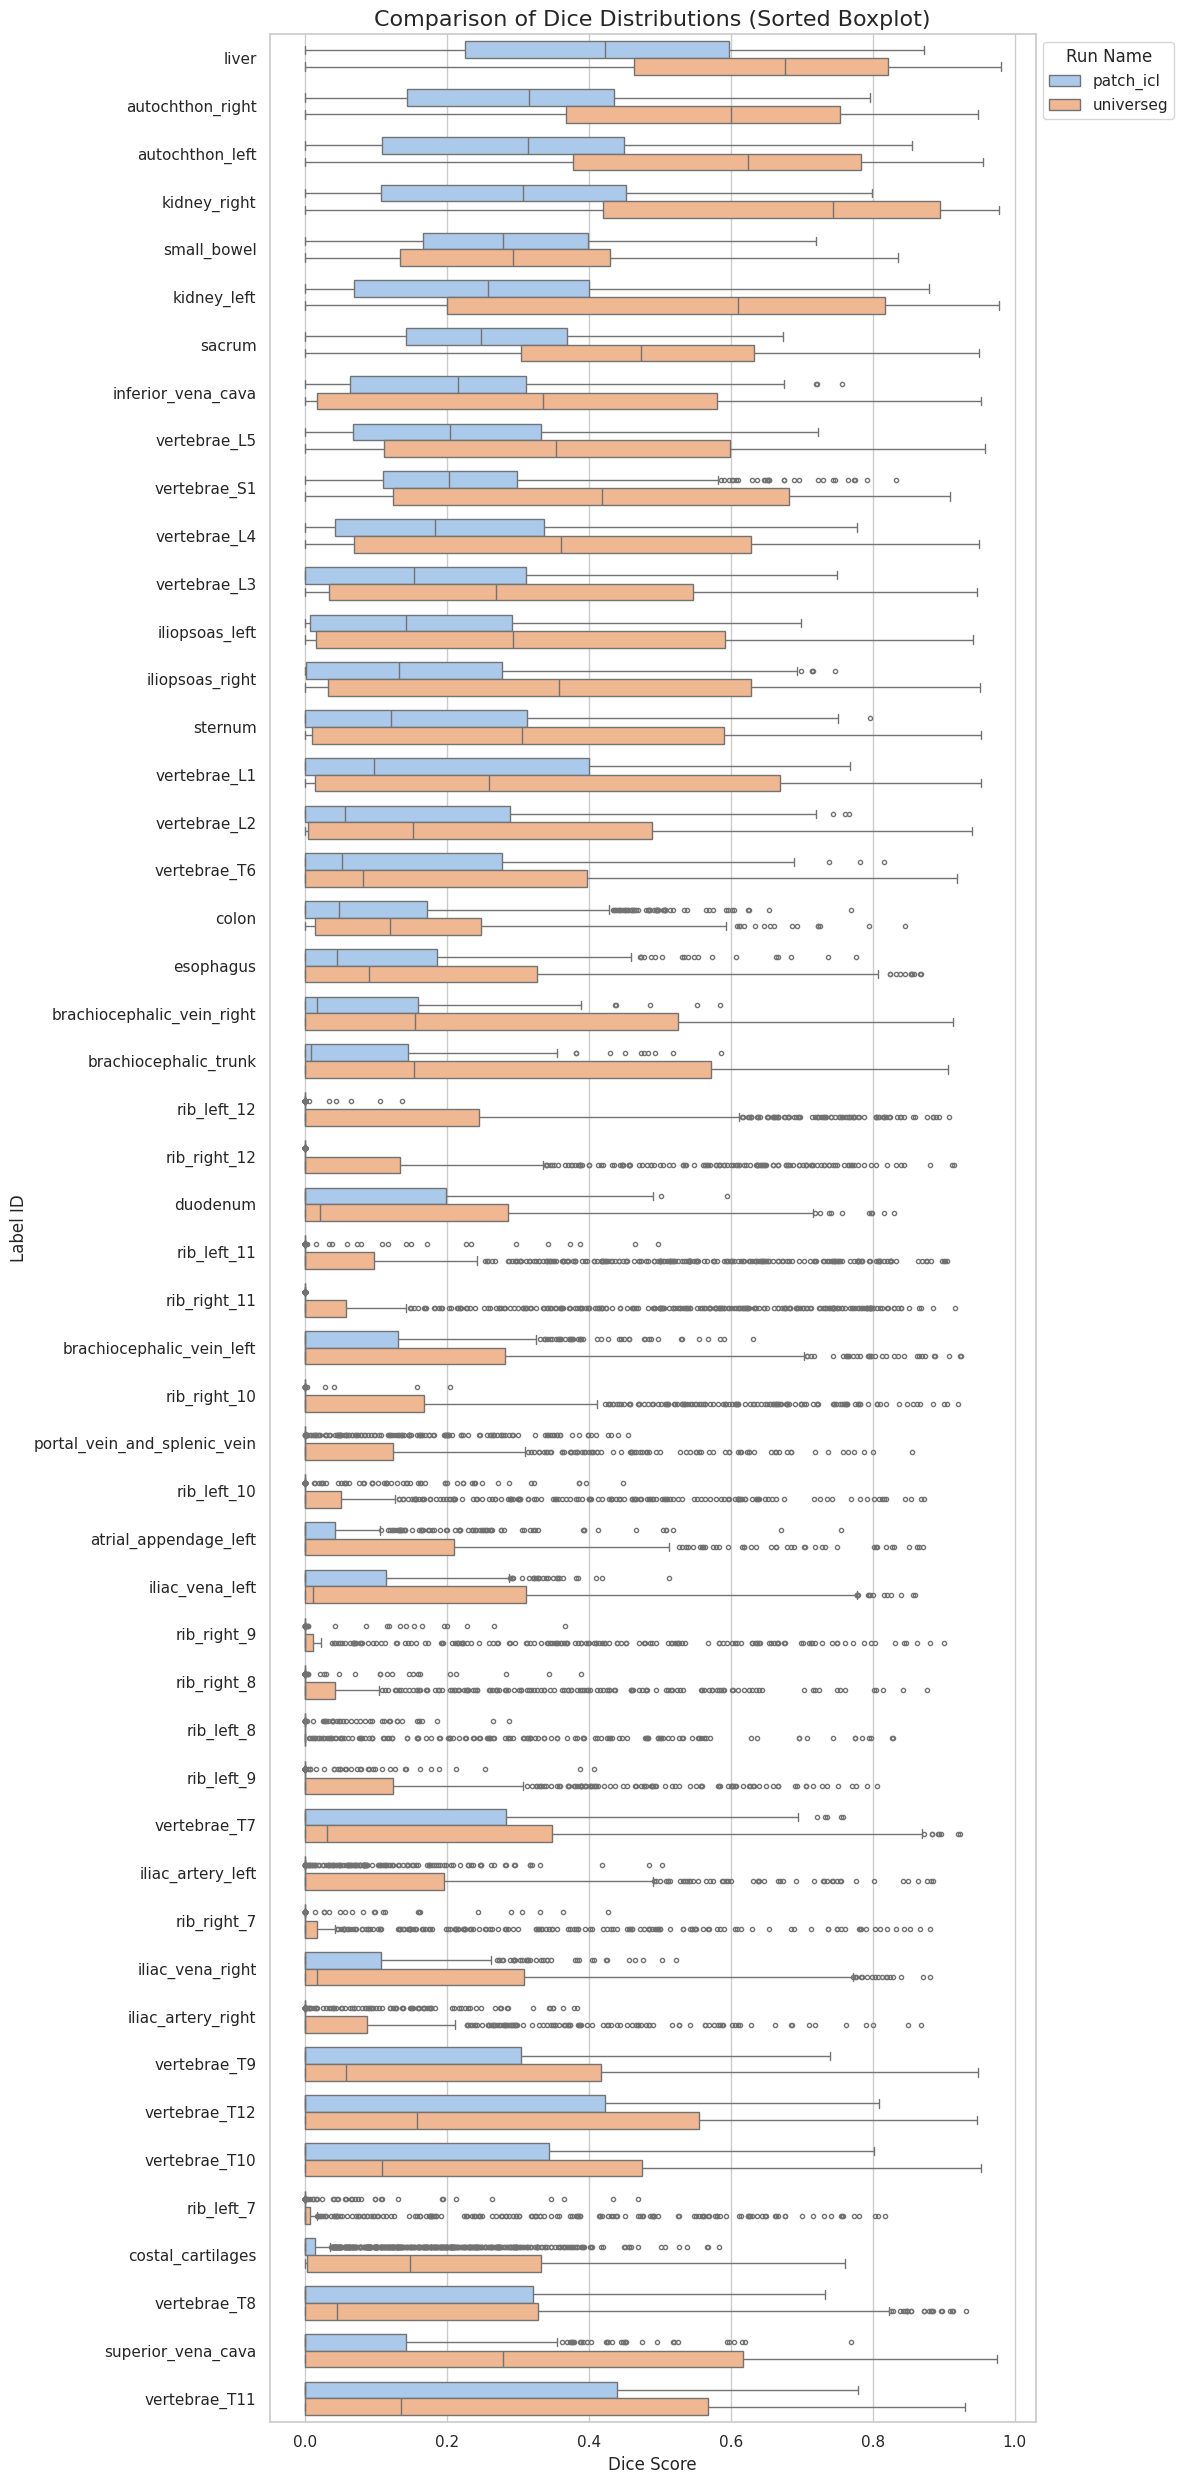

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. MERGE: Combine the two runs into a single DataFrame
combined_data = []

for run_name, run_data in runs.items():
    df_temp = run_data["df"].copy()
    # Add a column to identify the method (Run Name)
    df_temp["Run"] = run_name  
    combined_data.append(df_temp)

df_all = pd.concat(combined_data, ignore_index=True)

# 2. SORT: Calculate median Dice for the first run to sort labels
# This prevents the "random mess" look by creating a waterfall effect.
first_run_name = list(runs.keys())[0]

# Get the sort order (highest median to lowest)
sort_order = df_all[df_all['Run'] == first_run_name] \
             .groupby('label_id')['dice'].median() \
             .sort_values(ascending=False).index

# Apply the sort order to the 'label_id' column
df_all['label_id'] = pd.Categorical(
    df_all['label_id'], 
    categories=sort_order, 
    ordered=True
)

# 3. PLOT: Vertical Boxplot
# Tall height (25) is critical for 50 labels to be readable
plt.figure(figsize=(12, 25)) 
sns.set_theme(style="whitegrid")

sns.boxplot(
    data=df_all,
    x="dice",           # Metric on X axis
    y="label_id",       # Labels on Y axis
    hue="Run",          # Compare the two runs side-by-side
    orient="h",         # Horizontal orientation
    palette="pastel",   # Softer colors
    width=0.7,          # Adjust box width to fit tightly
    linewidth=1.0,      # Thinner lines for clarity
    fliersize=3         # Smaller outlier dots
)

plt.title('Comparison of Dice Distributions (Sorted Boxplot)', fontsize=16)
plt.xlabel('Dice Score')
plt.ylabel('Label ID')

# Move legend outside if it covers data
plt.legend(title='Run Name', loc='upper left', bbox_to_anchor=(1, 1)) 

plt.tight_layout()
plt.show()

In [5]:
df_all.label_id.unique().tolist()

['colon',
 'iliac_artery_left',
 'iliac_artery_right',
 'iliac_vena_left',
 'iliac_vena_right',
 'iliopsoas_left',
 'iliopsoas_right',
 'rib_right_12',
 'sacrum',
 'small_bowel',
 'atrial_appendage_left',
 'autochthon_left',
 'autochthon_right',
 'brachiocephalic_trunk',
 'brachiocephalic_vein_left',
 'brachiocephalic_vein_right',
 'costal_cartilages',
 'esophagus',
 'rib_left_7',
 'rib_left_8',
 'rib_right_7',
 'sternum',
 'superior_vena_cava',
 'vertebrae_T6',
 'vertebrae_T7',
 'vertebrae_T8',
 'inferior_vena_cava',
 'kidney_left',
 'liver',
 'rib_left_10',
 'rib_left_11',
 'rib_left_12',
 'rib_left_9',
 'rib_right_10',
 'rib_right_11',
 'rib_right_8',
 'rib_right_9',
 'vertebrae_L1',
 'vertebrae_T10',
 'vertebrae_T11',
 'vertebrae_T12',
 'vertebrae_T9',
 'duodenum',
 'kidney_right',
 'portal_vein_and_splenic_vein',
 'vertebrae_L2',
 'vertebrae_L3',
 'vertebrae_L4',
 'vertebrae_L5',
 'vertebrae_S1']

In [6]:
from pathlib import Path
totalseg_dir = Path("/nfs/data/nii/data1/Analysis/camaret___in_context_segmentation/ANALYSIS_20251122/data/totalseg")
df_label_stats = pd.read_csv(totalseg_dir / "label_stats.csv", index_col="label_id")
print(df_label_stats.columns)

Index(['category', 'occurrences', 'avg_volume', 'split'], dtype='object')


/tmp/ipykernel_2375668/140234543.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_dice_avg = df_all.groupby(['label_id', 'Run'], as_index=False)['dice'].mean()


patch_icl - Volume Correlation (Spearman): 0.84
universeg - Volume Correlation (Spearman): 0.73
patch_icl - Occurrence Correlation (Spearman): -0.03
universeg - Occurrence Correlation (Spearman): -0.09


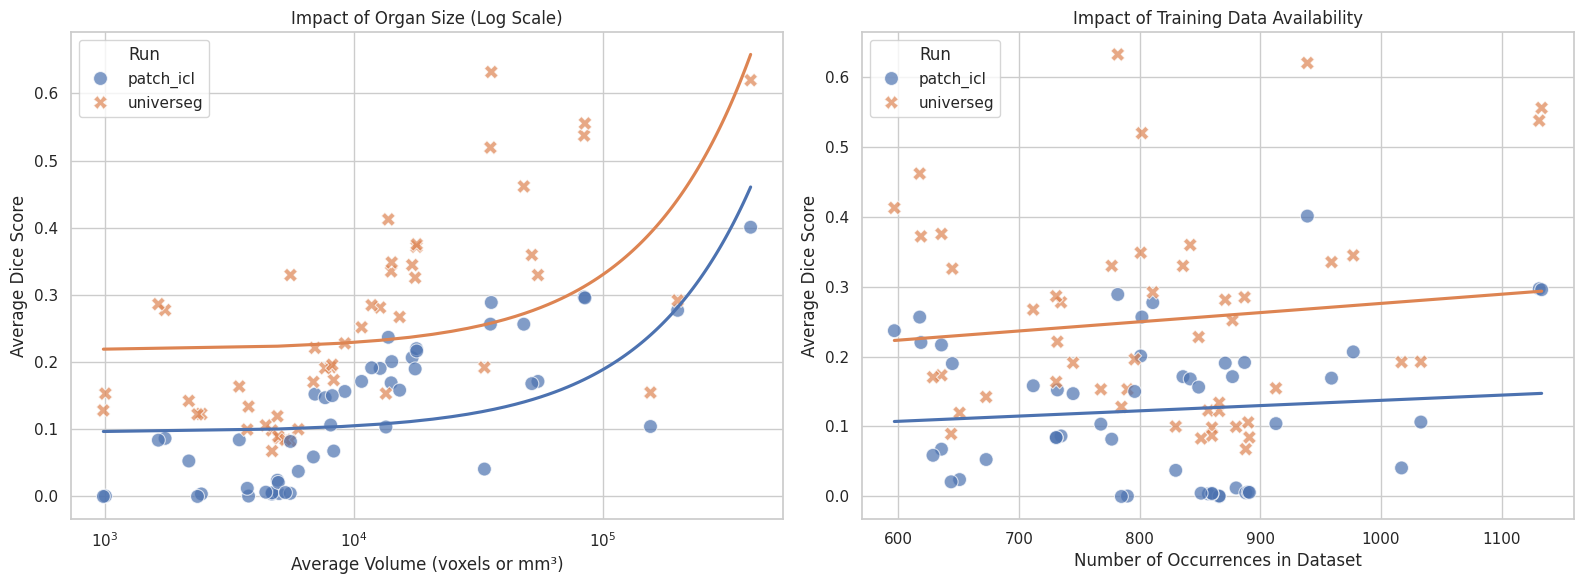

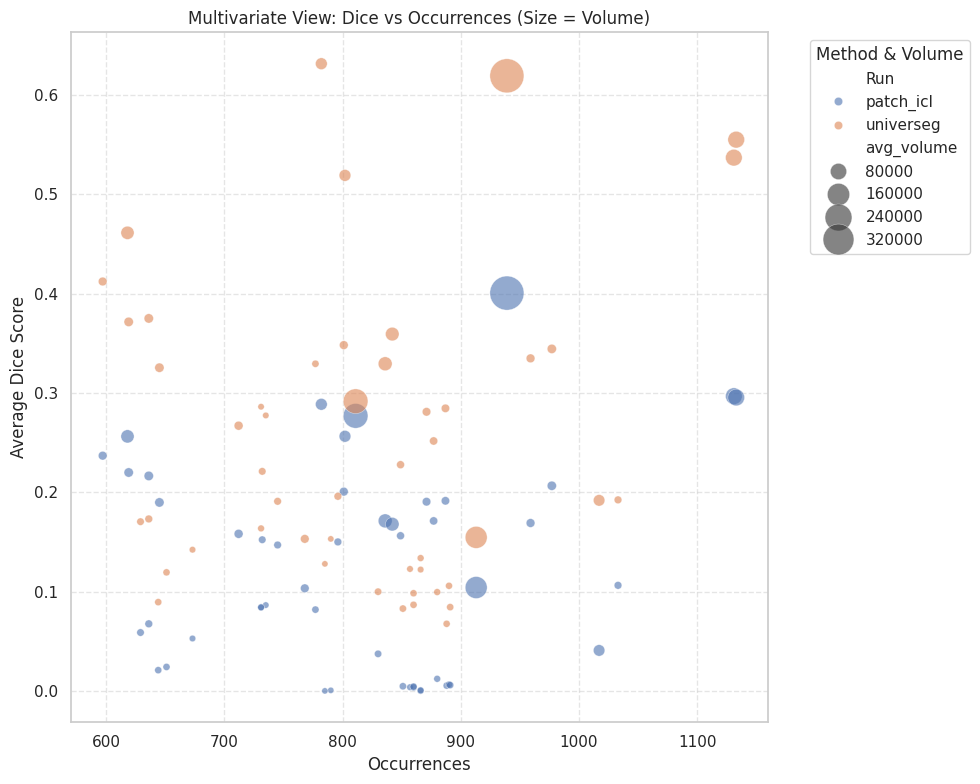

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

# 1. PREPARE DATA
# ---------------------------------------------------------
# Step A: Calculate average Dice per label for each method
# (Assuming 'df_all' is the combined dataframe from previous steps)
df_dice_avg = df_all.groupby(['label_id', 'Run'], as_index=False)['dice'].mean()

# Step B: Merge with your meta-data (volume & occurrences)
# specific_stats_df should have columns: ['label_id', 'avg_volume', 'occurences']
# If you don't have it loaded yet:
specific_stats_df = pd.read_csv(totalseg_dir / "label_stats.csv")

df_final = pd.merge(df_dice_avg, specific_stats_df, on='label_id')

# 2. PLOT: Dual Scatter Plot (Clearest Correlation View)
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

# --- Plot A: Volume vs Dice (Log Scale) ---
sns.scatterplot(
    data=df_final, 
    x="avg_volume", 
    y="dice", 
    hue="Run", 
    style="Run",
    s=100, alpha=0.7, 
    ax=axes[0]
)
# Add trend lines (optional, using regplot)
colors = sns.color_palette()
for i, method in enumerate(df_final['Run'].unique()):
    subset = df_final[df_final['Run'] == method]
    sns.regplot(
        data=subset, x="avg_volume", y="dice", 
        scatter=False, ax=axes[0], color=colors[i], ci=None
    )
    # Calculate Correlation (Spearman for non-linear volume relationships)
    corr, _ = spearmanr(subset['avg_volume'], subset['dice'])
    print(f"{method} - Volume Correlation (Spearman): {corr:.2f}")

axes[0].set_xscale("log") # Crucial for volume!
axes[0].set_title("Impact of Organ Size (Log Scale)")
axes[0].set_xlabel("Average Volume (voxels or mm³)")
axes[0].set_ylabel("Average Dice Score")

# --- Plot B: Occurrences vs Dice ---
sns.scatterplot(
    data=df_final, 
    x="occurrences", 
    y="dice", 
    hue="Run", 
    style="Run",
    s=100, alpha=0.7, 
    ax=axes[1]
)
# Add trend lines
for i, method in enumerate(df_final['Run'].unique()):
    subset = df_final[df_final['Run'] == method]
    sns.regplot(
        data=subset, x="occurrences", y="dice", 
        scatter=False, ax=axes[1], color=colors[i], ci=None
    )
    # Pearson is usually fine for counts
    corr, _ = spearmanr(subset['occurrences'], subset['dice'])
    print(f"{method} - Occurrence Correlation (Spearman): {corr:.2f}")

axes[1].set_title("Impact of Training Data Availability")
axes[1].set_xlabel("Number of Occurrences in Dataset")
axes[1].set_ylabel("Average Dice Score")

plt.tight_layout()
plt.show()

# 3. ALTERNATIVE: Multivariate Bubble Plot
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_final,
    x="occurrences",
    y="dice",
    size="avg_volume",  # Bubble size = Volume
    sizes=(20, 600),    # Range of bubble sizes
    hue="Run",
    alpha=0.6,
    palette="deep"
)
plt.title("Multivariate View: Dice vs Occurrences (Size = Volume)")
plt.xlabel("Occurrences")
plt.ylabel("Average Dice Score")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Method & Volume")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()